In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import os, warnings

warnings.filterwarnings('ignore')

# ── Configuration graphique globale ──────────────────────────────────────────
plt.rcParams['figure.dpi']        = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')
sns.set_palette('husl')

COLOR_PRIMARY = '#2C7BB6'
COLOR_ACCENT  = '#D7191C'

os.makedirs('figures', exist_ok=True)
print('✅ Environnement configuré.')

✅ Environnement configuré.


---
## 1. Chargement et Profiling du dataset

Cette première étape vise à **comprendre la structure brute du jeu de données** avant toute transformation.
Elle permet d'identifier les problèmes de qualité qui orienteront les choix de nettoyage.

### 1.1 — Chargement et vue d'ensemble

In [2]:
DATA_PATH = 'World-happiness-report-updated_2024.csv'
df = pd.read_csv(DATA_PATH,encoding='latin-1')

# ── Volumétrie ───────────────────────────────────────────────
n_rows      = df.shape[0]
n_cols      = df.shape[1]
n_countries = df['Country name'].nunique()
yr_min      = df['year'].min()
yr_max      = df['year'].max()
n_years     = df['year'].nunique()

print('=' * 60)
print('INFORMATIONS GÉNÉRALES')
print('=' * 60)
print(f'Fichier source   : {DATA_PATH}')
print(f'Dimensions       : {n_rows:,} lignes × {n_cols} colonnes')
print(f'Pays couverts    : {n_countries}')
print(f'Période          : {yr_min} → {yr_max}  ({n_years} années)')
print()
print('Types de données :')
print(df.dtypes)

INFORMATIONS GÉNÉRALES
Fichier source   : World-happiness-report-updated_2024.csv
Dimensions       : 2,363 lignes × 11 colonnes
Pays couverts    : 165
Période          : 2005 → 2023  (19 années)

Types de données :
Country name                            str
year                                  int64
Life Ladder                         float64
Log GDP per capita                  float64
Social support                      float64
Healthy life expectancy at birth    float64
Freedom to make life choices        float64
Generosity                          float64
Perceptions of corruption           float64
Positive affect                     float64
Negative affect                     float64
dtype: object


In [ ]:
# Aperçu des premières lignes
df.head(8)

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
0,Afghanistan,2008,3.724,7.350,0.451,50.5,0.718,0.164,0.882,0.414,0.258
1,Afghanistan,2009,4.402,7.509,0.552,50.8,0.679,0.187,0.850,0.481,0.237
2,Afghanistan,2010,4.758,7.614,0.539,51.1,0.600,0.118,0.707,0.517,0.275
3,Afghanistan,2011,3.832,7.581,0.521,51.4,0.496,0.160,0.731,0.480,0.267
4,Afghanistan,2012,3.783,7.661,0.521,51.7,0.531,0.234,0.776,0.614,0.268
5,Afghanistan,2013,3.572,7.680,0.484,52.0,0.578,0.059,0.823,0.547,0.273
6,Afghanistan,2014,3.131,7.671,0.526,52.3,0.509,0.102,0.871,0.492,0.375
7,Afghanistan,2015,3.983,7.654,0.529,52.6,0.389,0.078,0.881,0.491,0.339


### 1.2 — Analyse des valeurs manquantes

Les **valeurs manquantes** (NaN) peuvent biaiser les analyses et doivent être identifiées précisément
avant de choisir une stratégie de traitement.

In [4]:
# ── Calcul des manquants par colonne ─────────────────────────
missing_count = df.isnull().sum()
missing_pct   = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Nombre manquants': missing_count,
    'Pourcentage (%)' : missing_pct
}).sort_values('Nombre manquants', ascending=False)
missing_df = missing_df[missing_df['Nombre manquants'] > 0]

print('Valeurs manquantes par variable :')
print(missing_df.to_string())
print(f'\nTotal manquants : {df.isnull().sum().sum()}')
print(f'Taux global     : {df.isnull().sum().sum() / df.size * 100:.2f}%')
print('\n✔ Life Ladder (variable cible) : 0 valeur manquante.')

Valeurs manquantes par variable :
                                  Nombre manquants  Pourcentage (%)
Perceptions of corruption                      125             5.29
Generosity                                      81             3.43
Healthy life expectancy at birth                63             2.67
Freedom to make life choices                    36             1.52
Log GDP per capita                              28             1.18
Positive affect                                 24             1.02
Negative affect                                 16             0.68
Social support                                  13             0.55

Total manquants : 386
Taux global     : 1.49%

✔ Life Ladder (variable cible) : 0 valeur manquante.


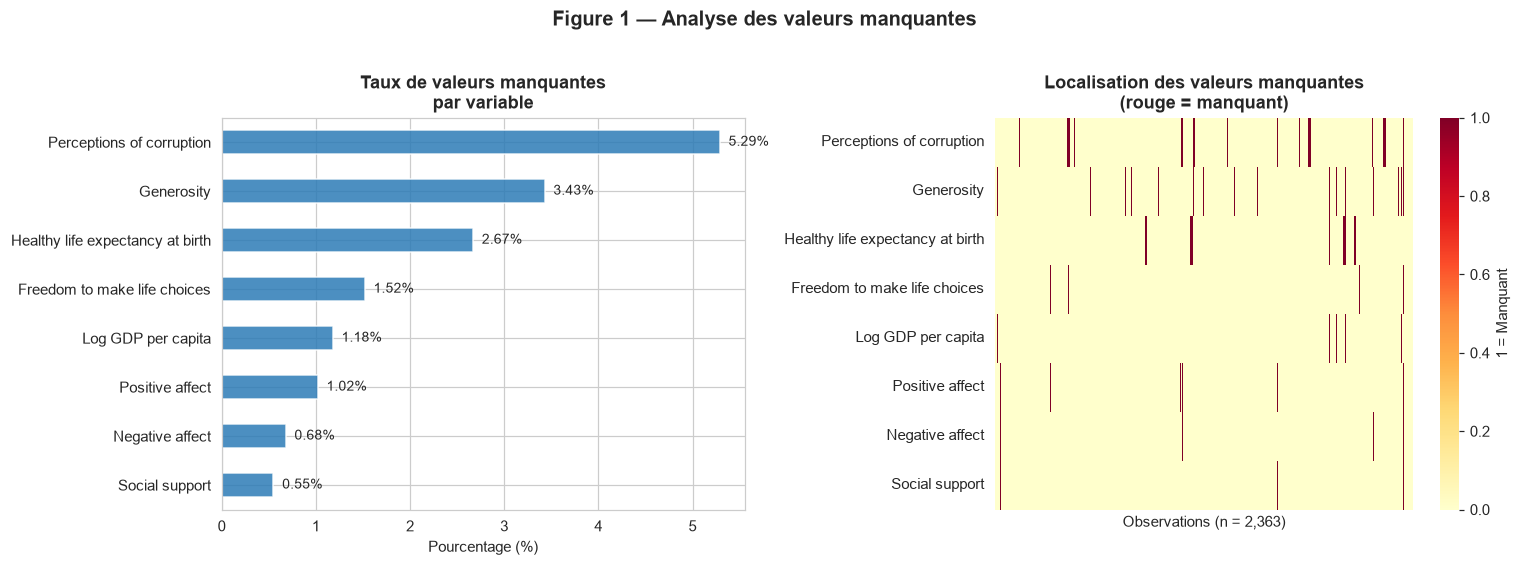

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Barplot des taux de manquants ─────────────────────────────
missing_df['Pourcentage (%)'].sort_values().plot(
    kind='barh', ax=axes[0], color=COLOR_PRIMARY, edgecolor='white', alpha=0.85
)
axes[0].set_title('Taux de valeurs manquantes\npar variable', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Pourcentage (%)')
for i, v in enumerate(missing_df['Pourcentage (%)'].sort_values()):
    axes[0].text(v + 0.05, i, f' {v:.2f}%', va='center', fontsize=9)

# ── Heatmap de localisation des manquants ─────────────────────
null_map = df[missing_df.index].isnull().astype(int)
sns.heatmap(null_map.T, cmap='YlOrRd', ax=axes[1], yticklabels=True,
            xticklabels=False, cbar_kws={'label': '1 = Manquant'})
axes[1].set_title('Localisation des valeurs manquantes\n(rouge = manquant)', fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'Observations (n = {len(df):,})')

plt.suptitle('Figure 1 — Analyse des valeurs manquantes', fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/01_missing_values.png', bbox_inches='tight')
plt.show()

### 1.3 — Doublons

In [6]:
n_full_dupes = df.duplicated().sum()
n_key_dupes  = df.duplicated(subset=['Country name', 'year']).sum()
obs_per_country = df['Country name'].value_counts()

print(f'Lignes identiques        : {n_full_dupes}')
print(f'Doublons (pays + année)  : {n_key_dupes}')
print('→ Aucun doublon. Structure panel confirmée (1 ligne = 1 pays × 1 année).')
print()
print('Distribution du nombre d\'observations par pays :')
print(obs_per_country.describe()[['min','max','mean','50%']].rename({'50%':'median'}).round(1))
print(f'\nPays avec le moins de données : {obs_per_country.idxmin()} ({obs_per_country.min()} obs.)')
print(f'Pays avec le plus de données  : {obs_per_country.idxmax()} ({obs_per_country.max()} obs.)')

Lignes identiques        : 0
Doublons (pays + année)  : 0
→ Aucun doublon. Structure panel confirmée (1 ligne = 1 pays × 1 année).

Distribution du nombre d'observations par pays :
min        1.0
max       18.0
mean      14.3
median    16.0
Name: count, dtype: float64

Pays avec le moins de données : Cuba (1 obs.)
Pays avec le plus de données  : Argentina (18 obs.)


### 1.4 — Statistiques descriptives

Les statistiques descriptives permettent d'évaluer l'**étendue**, la **distribution** et la **dispersion**
de chaque variable numérique. Elles révèlent notamment l'hétérogénéité des échelles.

> **Observation clé** : `Healthy life expectancy at birth` couvre [6.7, 74.6] ans,
> tandis que les indicateurs socio-économiques sont bornés dans [0, 1].
> Cette disparité d'échelle **justifie directement la normalisation** appliquée en Section 3.

In [7]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
year,2363.0,2014.764,5.059,2005.000,2011.000,2015.000,2019.000,2023.000
Life Ladder,2363.0,5.484,1.126,1.281,4.647,5.449,6.324,8.019
Log GDP per capita,2335.0,9.400,1.152,5.527,8.506,9.503,10.392,11.676
Social support,2350.0,0.809,0.121,0.228,0.744,0.834,0.904,0.987
Healthy life expectancy at birth,2300.0,63.402,6.843,6.720,59.195,65.100,68.552,74.600
Freedom to make life choices,2327.0,0.750,0.139,0.228,0.661,0.771,0.862,0.985
Generosity,2282.0,0.000,0.161,-0.340,-0.112,-0.022,0.094,0.700
Perceptions of corruption,2238.0,0.744,0.185,0.035,0.687,0.798,0.868,0.983
Positive affect,2339.0,0.652,0.106,0.179,0.572,0.663,0.737,0.884
Negative affect,2347.0,0.273,0.087,0.083,0.209,0.262,0.326,0.705


### 1.5 — Détection des outliers (méthode IQR)

La méthode **IQR (Interquartile Range)** identifie les valeurs en dehors de la plage :

$$[Q1 - 1.5 \times IQR \;,\; Q3 + 1.5 \times IQR]$$

> **Décision** : les outliers ne seront **pas supprimés**. Dans ce dataset, les valeurs extrêmes
> sont des données réelles (pays très pauvres vs. très riches, années de crise).
> Les supprimer biaiserait les analyses comparatives. Seule la valeur aberrante de **Haïti 2006**
> (`Healthy life expectancy = 6.72 ans`) est signalée comme erreur probable de saisie.

In [8]:
NUMERIC_COLS = [
    'Life Ladder', 'Log GDP per capita', 'Social support',
    'Healthy life expectancy at birth', 'Freedom to make life choices',
    'Generosity', 'Perceptions of corruption', 'Positive affect', 'Negative affect'
]

# ── Calcul des bornes IQR ────────────────────────────────────
outlier_rows = []
for col in NUMERIC_COLS:
    s   = df[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out  = ((s < lo) | (s > hi)).sum()
    outlier_rows.append({
        'Variable': col, 'Q1': round(Q1, 3), 'Q3': round(Q3, 3),
        'Borne inf.': round(lo, 3), 'Borne sup.': round(hi, 3),
        'N outliers': n_out, '% outliers': round(n_out / len(df) * 100, 2)
    })

pd.DataFrame(outlier_rows).set_index('Variable')

,Q1,Q3,Borne inf.,Borne sup.,N outliers,% outliers
Variable,,,,,,
Life Ladder,4.647,6.324,2.132,8.838,2,0.08
Log GDP per capita,8.506,10.392,5.677,13.222,1,0.04
Social support,0.744,0.904,0.504,1.144,48,2.03
Healthy life expectancy at birth,59.195,68.552,45.159,82.589,20,0.85
Freedom to make life choices,0.661,0.862,0.360,1.164,16,0.68
Generosity,-0.112,0.094,-0.421,0.402,39,1.65
Perceptions of corruption,0.687,0.868,0.416,1.139,194,8.21
Positive affect,0.572,0.737,0.324,0.984,9,0.38
Negative affect,0.209,0.326,0.033,0.502,31,1.31


In [9]:
# ── Anomalie Haïti — Healthy life expectancy ─────────────────
haiti = df[df['Country name'] == 'Haiti'][['Country name','year','Healthy life expectancy at birth']]
print('⚠  Valeurs anormales — Healthy life expectancy at birth (Haïti) :')
print(haiti.sort_values('year').to_string(index=False))
print()
print('Interprétation : les valeurs 6.72 (2006), 17.36 (2008) et 28.0 (2010)')
print('sont incohérentes avec la réalité (~52 ans selon OMS).')
print('→ Probable erreur de saisie dans la source. Traitée par interpolation intra-pays.')

⚠  Valeurs anormales — Healthy life expectancy at birth (Haïti) :
Country name  year  Healthy life expectancy at birth
       Haiti  2006                              6.72
       Haiti  2008                             17.36
       Haiti  2010                             28.00
       Haiti  2011                             33.32
       Haiti  2012                             38.64
       Haiti  2013                             43.96
       Haiti  2014                             49.28
       Haiti  2015                             54.60
       Haiti  2016                             54.90
       Haiti  2017                             55.20
       Haiti  2018                             55.50

Interprétation : les valeurs 6.72 (2006), 17.36 (2008) et 28.0 (2010)
sont incohérentes avec la réalité (~52 ans selon OMS).
→ Probable erreur de saisie dans la source. Traitée par interpolation intra-pays.


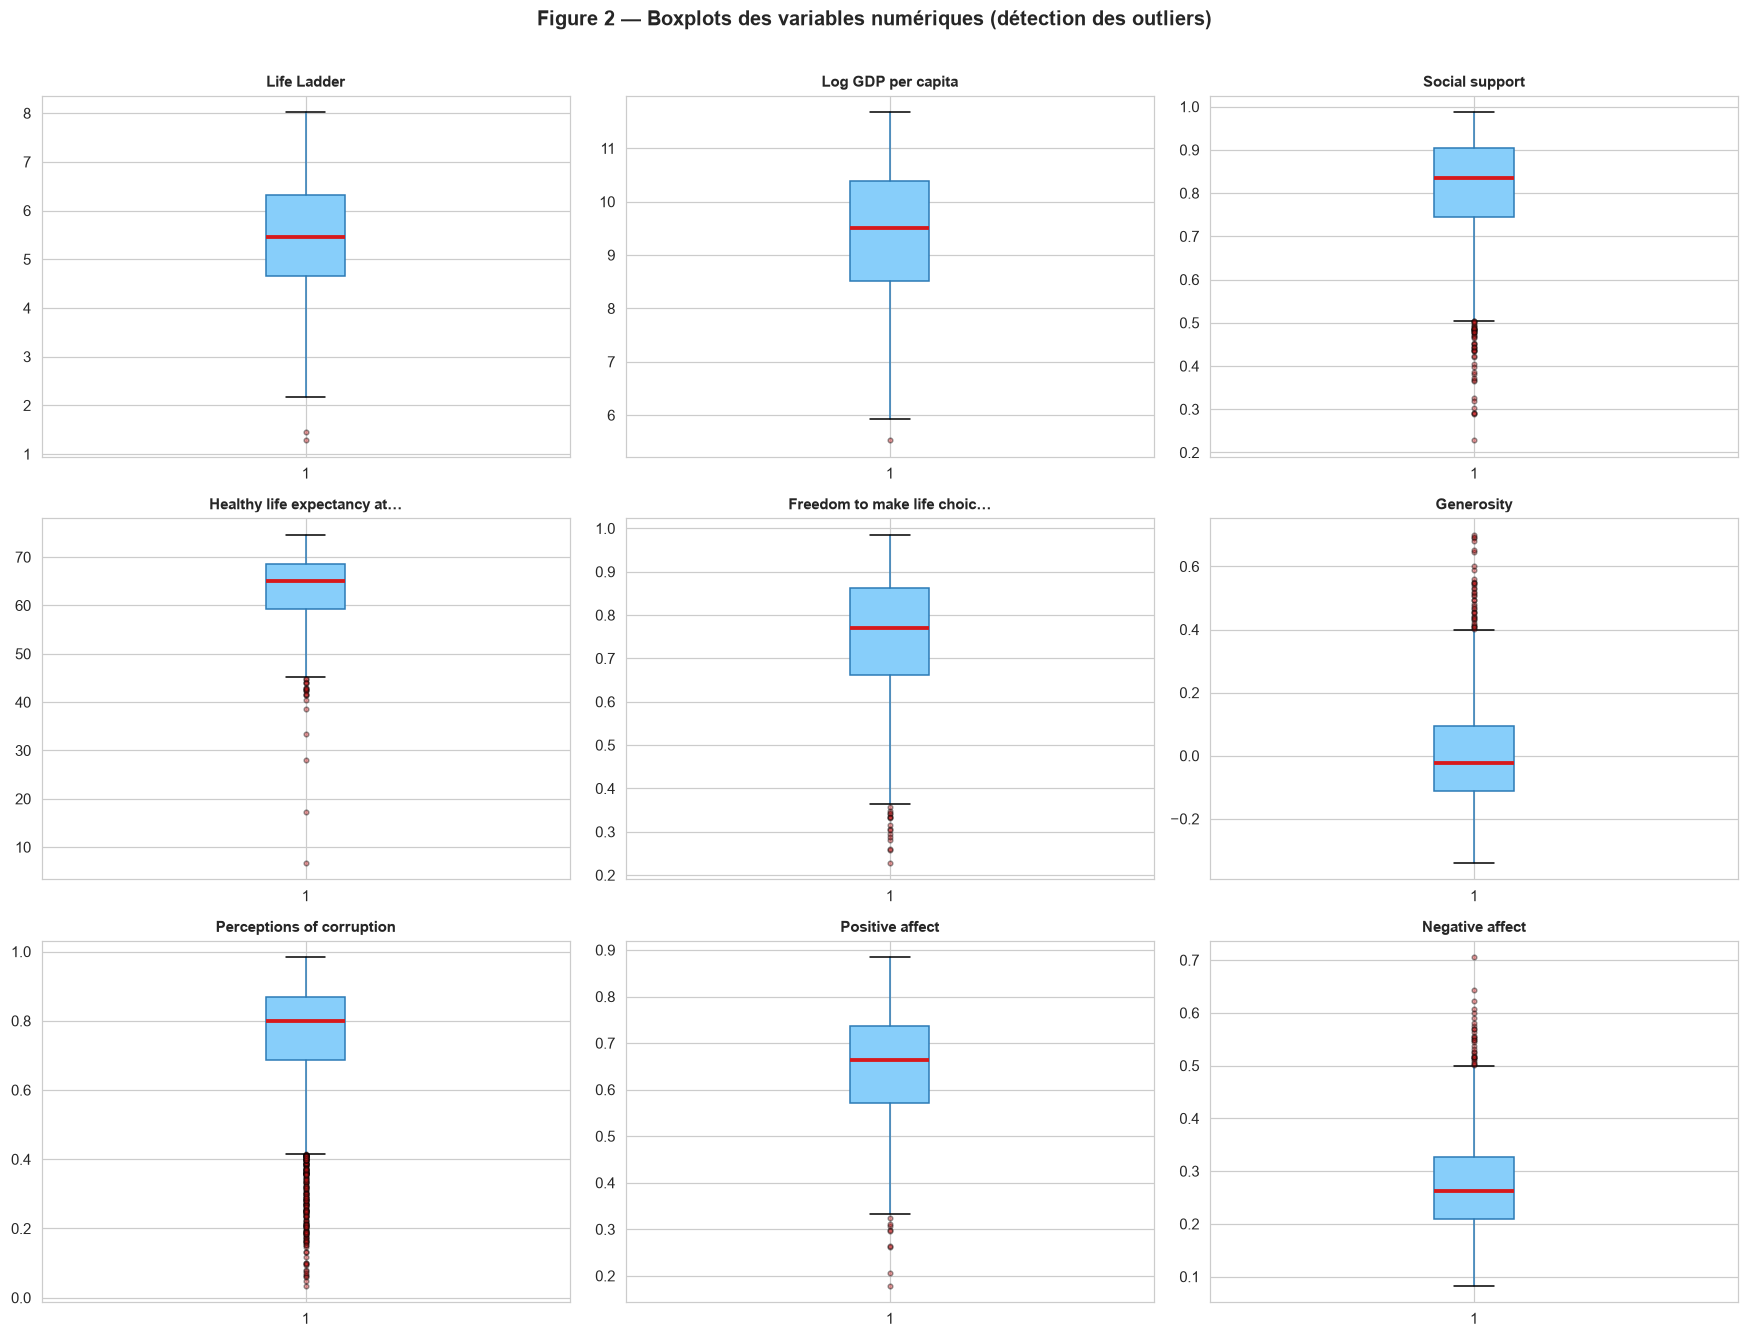

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    axes[i].boxplot(
        df[col].dropna(), patch_artist=True,
        boxprops=dict(facecolor='lightskyblue', color=COLOR_PRIMARY),
        medianprops=dict(color=COLOR_ACCENT, linewidth=2.5),
        whiskerprops=dict(color=COLOR_PRIMARY),
        flierprops=dict(marker='o', markerfacecolor=COLOR_ACCENT, markersize=3, alpha=0.4)
    )
    short = col if len(col) <= 26 else col[:26] + '…'
    axes[i].set_title(short, fontsize=9.5, fontweight='bold')

plt.suptitle('Figure 2 — Boxplots des variables numériques (détection des outliers)',
             fontsize=13, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/02_boxplots_outliers.png', bbox_inches='tight')
plt.show()

### 1.6 — Visualisations exploratoires (EDA)

Trois visualisations clés pour comprendre la structure du dataset :
1. Distribution de la variable cible `Life Ladder`
2. Corrélation entre toutes les variables
3. Classement des pays pour l'année la plus récente

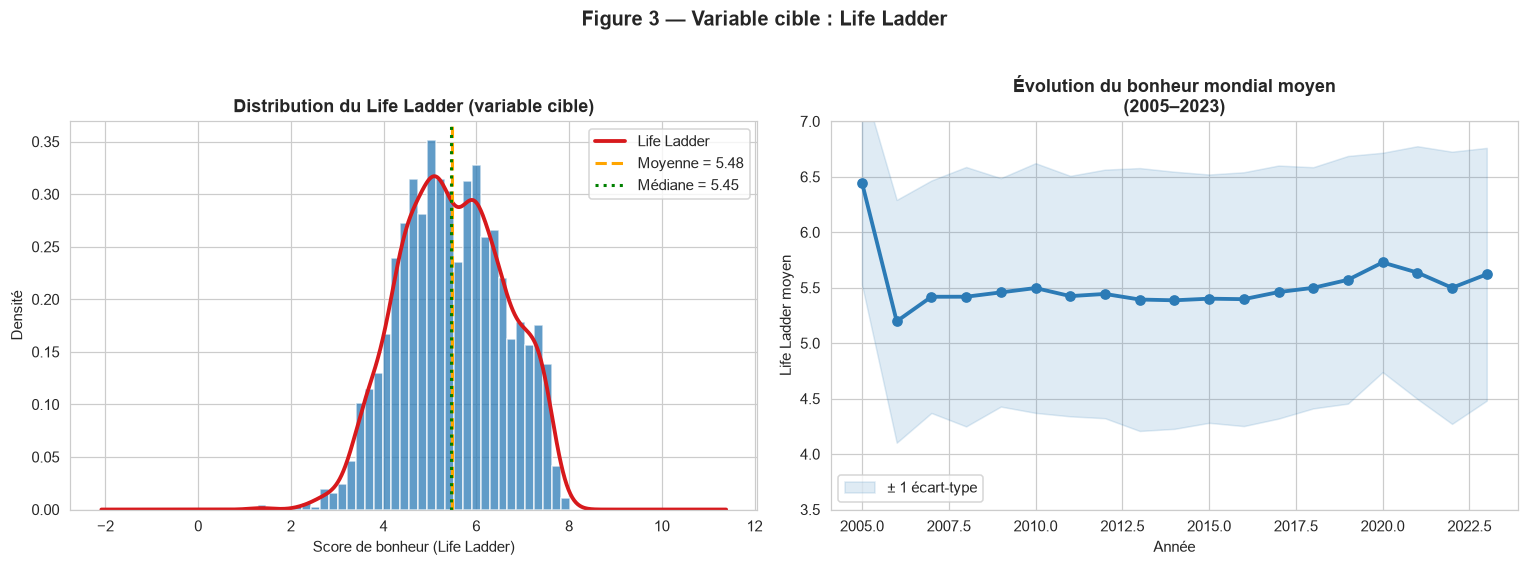

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Distribution du Life Ladder ──────────────────────────────
axes[0].hist(df['Life Ladder'], bins=35, color=COLOR_PRIMARY,
             edgecolor='white', alpha=0.75, density=True)
df['Life Ladder'].plot(kind='kde', ax=axes[0], color=COLOR_ACCENT, linewidth=2.5)
axes[0].axvline(df['Life Ladder'].mean(),   color='orange', linestyle='--', linewidth=2,
                label=f"Moyenne = {df['Life Ladder'].mean():.2f}")
axes[0].axvline(df['Life Ladder'].median(), color='green',  linestyle=':',  linewidth=2,
                label=f"Médiane = {df['Life Ladder'].median():.2f}")
axes[0].set_title('Distribution du Life Ladder (variable cible)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Score de bonheur (Life Ladder)')
axes[0].set_ylabel('Densité')
axes[0].legend()

# ── Évolution temporelle de la moyenne mondiale ──────────────
yearly = df.groupby('year')['Life Ladder'].agg(['mean', 'std']).reset_index()
axes[1].plot(yearly['year'], yearly['mean'], marker='o', color=COLOR_PRIMARY,
             linewidth=2.5, markersize=6)
axes[1].fill_between(yearly['year'],
                     yearly['mean'] - yearly['std'],
                     yearly['mean'] + yearly['std'],
                     alpha=0.15, color=COLOR_PRIMARY, label='± 1 écart-type')
axes[1].set_title('Évolution du bonheur mondial moyen\n(2005–2023)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Année')
axes[1].set_ylabel('Life Ladder moyen')
axes[1].set_ylim(3.5, 7)
axes[1].legend()

plt.suptitle('Figure 3 — Variable cible : Life Ladder', fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/03_life_ladder_analysis.png', bbox_inches='tight')
plt.show()

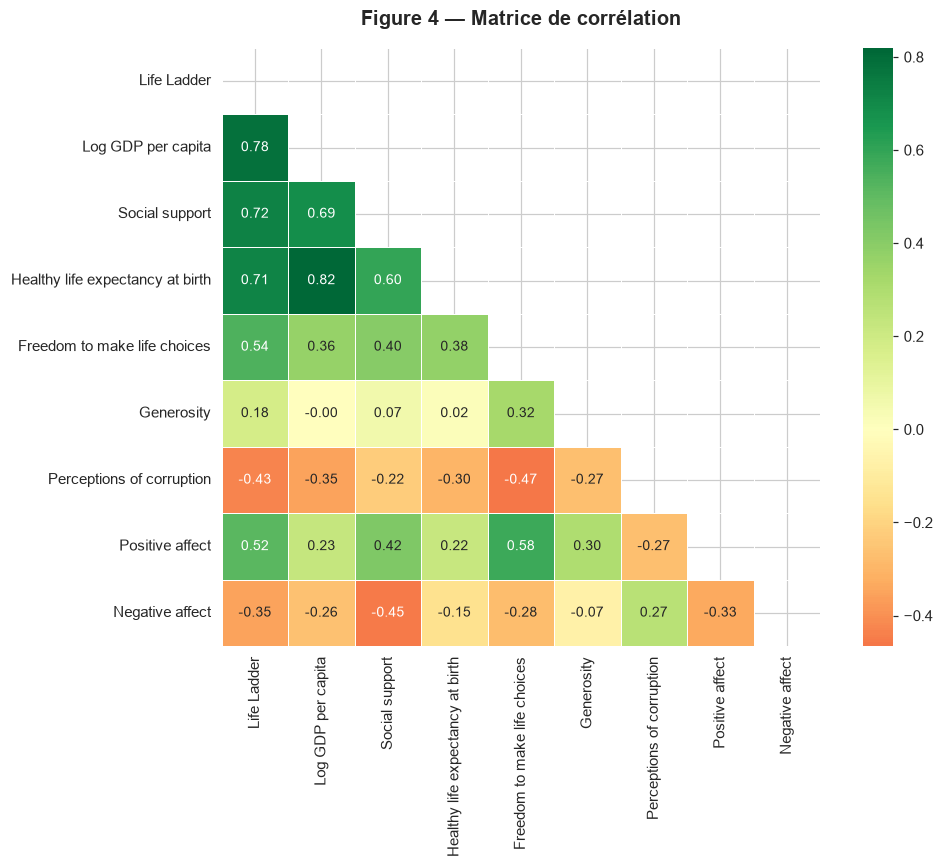

Corrélations avec Life Ladder (triées) :
  +0.784  Log GDP per capita ← forte corrélation positive
  +0.723  Social support ← forte corrélation positive
  +0.715  Healthy life expectancy at birth ← forte corrélation positive
  +0.538  Freedom to make life choices
  +0.515  Positive affect
  +0.177  Generosity
  -0.352  Negative affect ← corrélation négative
  -0.430  Perceptions of corruption ← corrélation négative


In [12]:
# ── Matrice de corrélation ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[NUMERIC_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, ax=ax, linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Figure 4 — Matrice de corrélation', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('figures/04_correlation_matrix.png', bbox_inches='tight')
plt.show()

# Corrélations avec Life Ladder (synthèse)
print('Corrélations avec Life Ladder (triées) :')
corr_ladder = corr['Life Ladder'].drop('Life Ladder').sort_values(ascending=False)
for col, val in corr_ladder.items():
    tag = ' ← forte corrélation positive' if val > 0.6 else (' ← corrélation négative' if val < -0.3 else '')
    print(f'  {val:+.3f}  {col}{tag}')

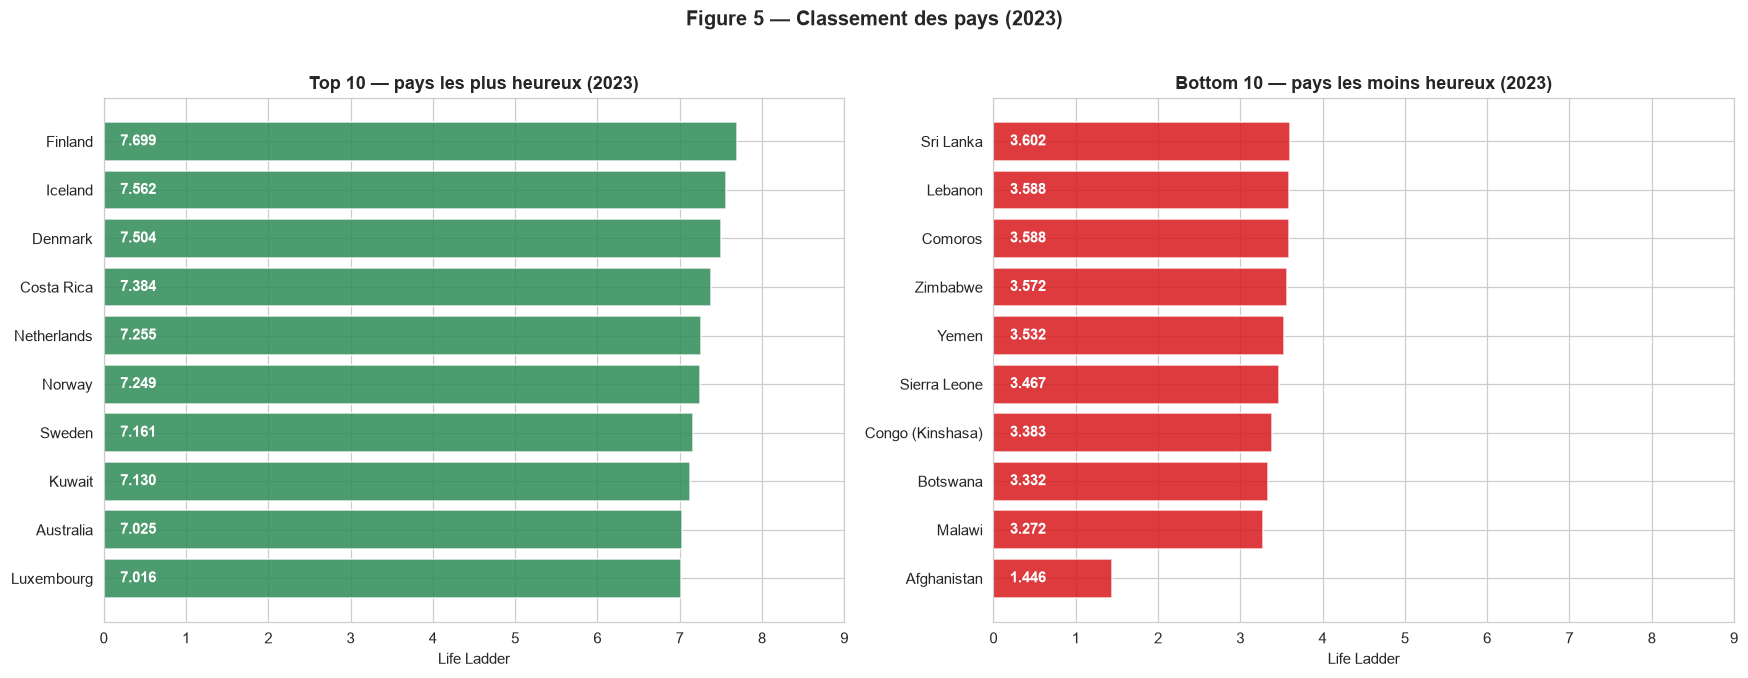

In [13]:
# ── Top 10 / Bottom 10 (année la plus récente) ───────────────
latest_year = df['year'].max()
df_latest   = df[df['year'] == latest_year].sort_values('Life Ladder', ascending=False)
top10       = df_latest.head(10)
bottom10    = df_latest.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top10['Country name'], top10['Life Ladder'], color='seagreen', edgecolor='white', alpha=0.85)
axes[0].set_title(f'Top 10 — pays les plus heureux ({latest_year})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Life Ladder')
axes[0].invert_yaxis()
axes[0].set_xlim(0, 9)
for i, v in enumerate(top10['Life Ladder']):
    axes[0].text(0.2, i, f'{v:.3f}', va='center', color='white', fontweight='bold')

axes[1].barh(bottom10['Country name'], bottom10['Life Ladder'], color=COLOR_ACCENT, edgecolor='white', alpha=0.85)
axes[1].set_title(f'Bottom 10 — pays les moins heureux ({latest_year})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Life Ladder')
axes[1].invert_yaxis()
axes[1].set_xlim(0, 9)
for i, v in enumerate(bottom10['Life Ladder']):
    axes[1].text(0.2, i, f'{v:.3f}', va='center', color='white', fontweight='bold')

plt.suptitle(f'Figure 5 — Classement des pays ({latest_year})', fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/05_rankings_latest_year.png', bbox_inches='tight')
plt.show()

---
## 2. Nettoyage des données

### 2.1 — Imputation des valeurs manquantes

#### Pourquoi ne pas supprimer les lignes ?

Le taux global de manquants est de **≈ 1.8%**. Supprimer les lignes concernées réduirait la couverture
géographique et temporelle, ce qui est préjudiciable pour les analyses de tendances et les dashboards.

#### Pourquoi ne pas imputer par la moyenne globale directement ?

Le dataset est un **panel temporel** (pays × année). Les valeurs d'un pays suivent une trajectoire
cohérente d'année en année. Imputer avec la moyenne mondiale ignorerait cette structure
et introduirait un biais (ex : imputer le PIB afghan avec la moyenne mondiale serait très éloigné de la réalité).

#### Stratégie choisie — 3 passes successives

| Passe | Méthode | Raison |
|---|---|---|
| 1 | **Interpolation linéaire intra-pays** | Préserve les tendances chronologiques — méthode la plus précise |
| 2 | **Forward fill / Backward fill intra-pays** | Gère les extrémités de séries non couvertes par l'interpolation |
| 3 | **Médiane globale** | Dernier recours (pays sans aucune donnée dans la colonne) |

> **Pourquoi la médiane et pas la moyenne ?**  
> Les distributions de `Perceptions of corruption` et `Generosity` sont asymétriques.
> La médiane est plus robuste face aux valeurs extrêmes que la moyenne.

In [14]:
df_clean = df.copy()
df_clean = df_clean.sort_values(['Country name', 'year']).reset_index(drop=True)

COLS_TO_IMPUTE = [c for c in NUMERIC_COLS if c != 'Life Ladder']

print(f'{"Variable":<47}  {"Avant":>6}  {"Après":>6}')
print('-' * 62)

for col in COLS_TO_IMPUTE:
    n_before = df_clean[col].isnull().sum()

    # Passe 1 — interpolation linéaire intra-pays
    df_clean[col] = df_clean.groupby('Country name')[col].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both')
    )
    # Passe 2 — ffill + bfill intra-pays
    df_clean[col] = df_clean.groupby('Country name')[col].transform(
        lambda x: x.ffill().bfill()
    )
    # Passe 3 — médiane globale (dernier recours)
    df_clean[col] = df_clean[col].fillna(df[col].median())

    n_after = df_clean[col].isnull().sum()
    print(f'{col:<47}  {n_before:>6}  {n_after:>6}')

total_remaining = df_clean.isnull().sum().sum()
assert total_remaining == 0, f'Valeurs manquantes résiduelles : {total_remaining}'
print(f'\n✅ Aucune valeur manquante résiduelle.')

Variable                                          Avant   Après
--------------------------------------------------------------
Log GDP per capita                                   28       0
Social support                                       13       0
Healthy life expectancy at birth                     63       0
Freedom to make life choices                         36       0
Generosity                                           81       0
Perceptions of corruption                           125       0
Positive affect                                      24       0
Negative affect                                      16       0

✅ Aucune valeur manquante résiduelle.


### 2.2 & 2.3 — Correction des types et renommage (snake_case)

Les colonnes sont renommées en **snake_case** pour faciliter l'usage en Python
et l'intégration dans des outils BI

In [15]:
# ── Correction des types ─────────────────────────────────────
df_clean['year'] = df_clean['year'].astype(int)
for col in NUMERIC_COLS:
    df_clean[col] = df_clean[col].astype(float)

# ── Renommage snake_case ─────────────────────────────────────
COLUMN_MAP = {
    'Country name'                     : 'country',
    'year'                             : 'year',
    'Life Ladder'                      : 'life_ladder',
    'Log GDP per capita'               : 'log_gdp_per_capita',
    'Social support'                   : 'social_support',
    'Healthy life expectancy at birth' : 'healthy_life_expectancy',
    'Freedom to make life choices'     : 'freedom',
    'Generosity'                       : 'generosity',
    'Perceptions of corruption'        : 'corruption',
    'Positive affect'                  : 'positive_affect',
    'Negative affect'                  : 'negative_affect'
}
df_clean.rename(columns=COLUMN_MAP, inplace=True)

print('Colonnes finales après renommage :')
for col in df_clean.columns:
    print(f'  • {col}  ({df_clean[col].dtype})')

Colonnes finales après renommage :
  • country  (str)
  • year  (int64)
  • life_ladder  (float64)
  • log_gdp_per_capita  (float64)
  • social_support  (float64)
  • healthy_life_expectancy  (float64)
  • freedom  (float64)
  • generosity  (float64)
  • corruption  (float64)
  • positive_affect  (float64)
  • negative_affect  (float64)


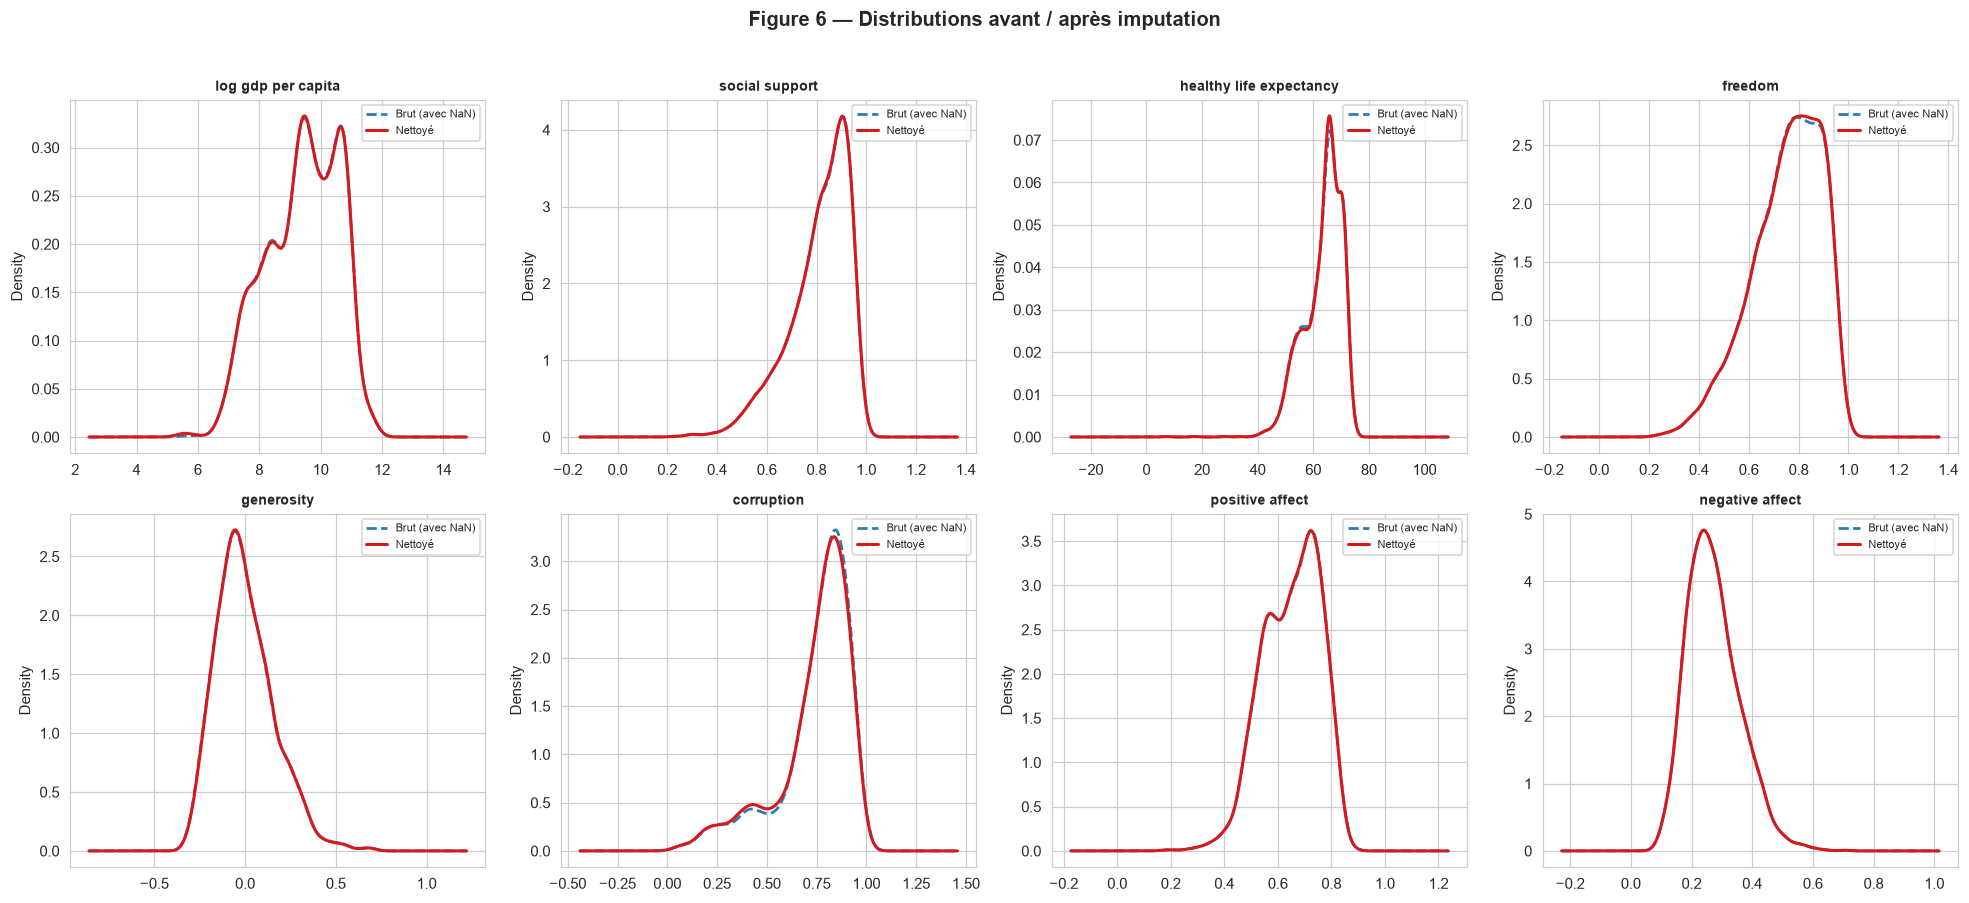

→ Les distributions sont quasi-identiques : l'imputation a préservé la forme des données.


In [16]:
# ── Comparaison avant / après imputation ─────────────────────
NUMERIC_FEATURES = [
    'log_gdp_per_capita', 'social_support', 'healthy_life_expectancy',
    'freedom', 'generosity', 'corruption', 'positive_affect', 'negative_affect'
]
ORIG_NAMES = {v: k for k, v in COLUMN_MAP.items()}  # snake → original

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_FEATURES):
    orig = ORIG_NAMES[col]
    df[orig].dropna().plot(kind='kde', ax=axes[i], color=COLOR_PRIMARY,
                           linestyle='--', linewidth=1.8, label='Brut (avec NaN)')
    df_clean[col].plot(kind='kde', ax=axes[i], color=COLOR_ACCENT,
                       linewidth=2, label='Nettoyé')
    axes[i].set_title(col.replace('_', ' '), fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=7)
    axes[i].set_xlabel('')

plt.suptitle('Figure 6 — Distributions avant / après imputation',
             fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/06_imputation_comparison.png', bbox_inches='tight')
plt.show()
print('→ Les distributions sont quasi-identiques : l\'imputation a préservé la forme des données.')

---
## 3. Pre-processing : Normalisation et Standardisation

### Pourquoi normaliser ?

Le dataset présente une **hétérogénéité d'échelles** importante :

| Variable | Échelle |
|---|---|
| `healthy_life_expectancy` | 6 – 75 **années** |
| `log_gdp_per_capita` | 5.5 – 11.7 (log) |
| `social_support`, `freedom`, etc. | 0 – 1 |

Sans normalisation, `healthy_life_expectancy` **écraserait** tous les autres indicateurs
dans les visualisations comparatives (radar charts, heatmaps) et fausserait
les algorithmes sensibles aux échelles (k-means, ACP).

**Deux jeux de colonnes créés**, selon l'usage :
- **Min-Max** → visualisations et dashboards
- **Z-score** → analyses statistiques et modélisation

### 3.1 — Normalisation Min-Max `[0, 1]`

$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

**Interprétation** : `0` = valeur minimale mondiale, `1` = valeur maximale mondiale.

**Usage** : comparaisons visuelles entre pays (radar charts), heatmaps de pays,
indicateurs agrégés dans l'outil BI.

**Limite** : sensible aux outliers extrêmes (un seul pays en bas ou en haut tire toute l'échelle).

> `life_ladder` est **exclu** de la normalisation : son échelle originale (1–8) est directement
> interprétable par les utilisateurs du dashboard (échelle de Cantril).

In [ ]:
scaler_mm = MinMaxScaler()
mm_values = scaler_mm.fit_transform(df_clean[NUMERIC_FEATURES])
mm_cols   = {f'{c}_minmax': mm_values[:, i] for i, c in enumerate(NUMERIC_FEATURES)}
df_clean  = pd.concat([df_clean, pd.DataFrame(mm_cols, index=df_clean.index)], axis=1)

print(f'✅ {len(mm_cols)} colonnes Min-Max créées (suffixe _minmax).')
print()

check = df_clean[[f'{c}_minmax' for c in NUMERIC_FEATURES]].agg(['min', 'max'])
check

✅ 8 colonnes Min-Max créées (suffixe _minmax).



,log_gdp_per_capita_minmax,social_support_minmax,healthy_life_expectancy_minmax,freedom_minmax,generosity_minmax,corruption_minmax,positive_affect_minmax,negative_affect_minmax
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### 3.2 — Standardisation Z-score `(µ = 0, σ = 1)`

$$z = \frac{x - \mu}{\sigma}$$

**Interprétation** : `z = +2` signifie « 2 écarts-types **au-dessus** de la moyenne mondiale ».

**Usage** : analyses statistiques (ACP, corrélation partielle), clustering (k-means),
algorithmes de machine learning, score composite (Section 4.4).

**Avantage vs Min-Max** : plus robuste — les outliers ne distordent pas l'échelle
puisque la transformée dépend de la moyenne et non des extrêmes.

In [18]:
scaler_std = StandardScaler()
std_values = scaler_std.fit_transform(df_clean[NUMERIC_FEATURES])
std_cols   = {f'{c}_zscore': std_values[:, i] for i, c in enumerate(NUMERIC_FEATURES)}
df_clean   = pd.concat([df_clean, pd.DataFrame(std_cols, index=df_clean.index)], axis=1)

print(f'✅ {len(std_cols)} colonnes Z-score créées (suffixe _zscore).')
print()

# Vérification : µ ≈ 0 et σ ≈ 1 pour chaque colonne
check_z = df_clean[[f'{c}_zscore' for c in NUMERIC_FEATURES]].agg(['mean', 'std']).round(4)
check_z

✅ 8 colonnes Z-score créées (suffixe _zscore).



,log_gdp_per_capita_zscore,social_support_zscore,healthy_life_expectancy_zscore,freedom_zscore,generosity_zscore,corruption_zscore,positive_affect_zscore,negative_affect_zscore
mean,-0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000
std,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002


---
## 4. Feature Engineering

Quatre nouvelles variables sont créées pour **enrichir le dataset** et faciliter les analyses :

| Variable créée | Type | Objectif |
|---|---|---|
| `happiness_category` | Catégorielle ordinale | Segmentation pour filtres dashboard |
| `life_ladder_yoy` | Numérique | Identifier la progression/régression annuelle |
| `net_affect` | Numérique | Solde émotionnel subjectif |
| `economic_wellbeing_score` | Numérique | Score composite des déterminants économiques |

### 4.1 — `happiness_category` : catégorie ordinale de bonheur

Le `life_ladder` est découpé en 5 classes ordinals sur la base de la distribution observée.
Les seuils sont fixés à 3.5, 5.0, 6.0 et 7.0, correspondant aux **transitions naturelles** du dataset.

| Catégorie | Seuil | Contexte typique |
|---|---|---|
| Très malheureux | < 3.5 | Pays en crise grave (conflits, famines) |
| Malheureux | 3.5 – 5.0 | Pays à faible développement |
| Modérément heureux | 5.0 – 6.0 | Pays émergents |
| Heureux | 6.0 – 7.0 | Pays développés |
| Très heureux | ≥ 7.0 | Pays nordiques, leaders |


In [26]:
CAT_ORDER = ['Très malheureux', 'Malheureux', 'Modérément heureux', 'Heureux', 'Très heureux']

def categorize_happiness(score):
    if score < 3.5:   return 'Très malheureux'
    elif score < 5.0: return 'Malheureux'
    elif score < 6.0: return 'Modérément heureux'
    elif score < 7.0: return 'Heureux'
    else:             return 'Très heureux'

df_clean['happiness_category'] = pd.Categorical(
    df_clean['life_ladder'].apply(categorize_happiness),
    categories=CAT_ORDER, ordered=True
)

print('Distribution des catégories :')
cat_dist = df_clean['happiness_category'].value_counts().sort_index()
for cat, cnt in cat_dist.items():
    bar = '█' * int(cnt / 30)
    print(f'  {cat:<22}  {cnt:>4} obs. ({cnt/len(df_clean)*100:.1f}%)  {bar}')

Distribution des catégories :
  Très malheureux           77 obs. (3.3%)  ██
  Malheureux               763 obs. (32.3%)  █████████████████████████
  Modérément heureux       723 obs. (30.6%)  ████████████████████████
  Heureux                  538 obs. (22.8%)  █████████████████
  Très heureux             262 obs. (11.1%)  ████████


### 4.2 — `life_ladder_yoy` : variation annuelle (Year-over-Year)

Différence du score de bonheur d'une année à l'autre, **calculée par pays**.

$$\text{yoy}_{t} = \text{life\_ladder}_{t} - \text{life\_ladder}_{t-1}$$

**Usage** : identifier les pays en progression ou régression rapide, détecter les effets de chocs
(pandémie COVID-19 en 2020, crises politiques, guerres).

> Les valeurs `NaN` pour la **première année observée** de chaque pays sont **intentionnelles** —
> il n'existe pas d'année précédente à cette date.

In [20]:
df_clean = df_clean.sort_values(['country', 'year'])
df_clean['life_ladder_yoy'] = df_clean.groupby('country')['life_ladder'].diff()

n_nan = df_clean['life_ladder_yoy'].isnull().sum()
print(f'life_ladder_yoy créé. NaN intentionnels (1ère année/pays) : {n_nan}')
print()
print('Statistiques de la variation annuelle :')
print(df_clean['life_ladder_yoy'].describe().round(4))
print()

# Pays avec les plus fortes variations positives (dernière année)
latest = df_clean[df_clean['year'] == df_clean['year'].max()]
print('Top 5 progressions (dernière année) :')
print(latest.nlargest(5, 'life_ladder_yoy')[['country', 'year', 'life_ladder', 'life_ladder_yoy']].to_string(index=False))
print('\nTop 5 régressions (dernière année) :')
print(latest.nsmallest(5, 'life_ladder_yoy')[['country', 'year', 'life_ladder', 'life_ladder_yoy']].to_string(index=False))

life_ladder_yoy créé. NaN intentionnels (1ère année/pays) : 165

Statistiques de la variation annuelle :
count    2198.0000
mean        0.0128
std         0.3887
min        -1.9990
25%        -0.1820
50%         0.0180
75%         0.2160
max         1.6630
Name: life_ladder_yoy, dtype: float64

Top 5 progressions (dernière année) :
     country  year  life_ladder  life_ladder_yoy
     Lebanon  2023        3.588            1.236
  Mozambique  2023        5.704            0.964
Sierra Leone  2023        3.467            0.907
       India  2023        4.676            0.746
      Kosovo  2023        6.878            0.718

Top 5 régressions (dernière année) :
            country  year  life_ladder  life_ladder_yoy
             Israel  2023        6.783           -0.879
Congo (Brazzaville)  2023        4.954           -0.851
       South Africa  2023        5.076           -0.505
             Guinea  2023        4.827           -0.490
          Lithuania  2023        6.553           -0.48

### 4.3 — `net_affect` : solde émotionnel

$$\text{net\_affect} = \text{positive\_affect} - \text{negative\_affect}$$

Le `life_ladder` mesure l'**évaluation cognitive** de la vie (« Comment évaluez-vous votre vie ? »).
Le `net_affect` capture la **dimension émotionnelle** du bien-être (expériences quotidiennes).
Ces deux dimensions sont complémentaires et **indépendantes** : un pays peut avoir un score cognitif
élevé mais un ressenti émotionnel négatif (ex : pays sous forte pression sociale).

- Valeur **> 0** : équilibre émotionnel favorable
- Valeur **< 0** : prédominance des émotions négatives

In [21]:
df_clean['net_affect'] = df_clean['positive_affect'] - df_clean['negative_affect']

print('net_affect créé.')
print(f'  min   = {df_clean["net_affect"].min():.3f}')
print(f'  max   = {df_clean["net_affect"].max():.3f}')
print(f'  moyen = {df_clean["net_affect"].mean():.3f}')
print()

# Corrélation avec Life Ladder
r_affect = df_clean[['life_ladder', 'net_affect']].corr().iloc[0, 1]
print(f'Corrélation net_affect ↔ life_ladder : r = {r_affect:.3f}')

net_affect créé.
  min   = -0.428
  max   = 0.717
  moyen = 0.378

Corrélation net_affect ↔ life_ladder : r = 0.540


### 4.4 — `economic_wellbeing_score` : score composite pondéré

Synthèse des **3 principaux déterminants économico-sanitaires** du bonheur,
identifiés par la littérature WHR comme les plus corrélés au `life_ladder` :

$$\text{score} = 0.35 \times z(\text{gdp}) + 0.35 \times z(\text{social}) + 0.30 \times z(\text{santé})$$

| Composante | Poids | Corrélation avec Life Ladder |
|---|---|---|
| `log_gdp_per_capita` | 35% | r ≈ +0.78 |
| `social_support` | 35% | r ≈ +0.72 |
| `healthy_life_expectancy` | 30% | r ≈ +0.72 |

Les **versions Z-score** sont utilisées pour que chaque composante contribue de manière équilibrée,
indépendamment de son échelle d'origine.

In [22]:
df_clean['economic_wellbeing_score'] = (
    df_clean['log_gdp_per_capita_zscore']       * 0.35
    + df_clean['social_support_zscore']         * 0.35
    + df_clean['healthy_life_expectancy_zscore'] * 0.30
)

r_ebs = df_clean[['life_ladder', 'economic_wellbeing_score']].corr().iloc[0, 1]
print(f'economic_wellbeing_score créé.')
print(f'  Corrélation avec life_ladder : r = {r_ebs:.3f}  (valide la pertinence du score composite)')
print(f'  min = {df_clean["economic_wellbeing_score"].min():.3f}')
print(f'  max = {df_clean["economic_wellbeing_score"].max():.3f}')

economic_wellbeing_score créé.
  Corrélation avec life_ladder : r = 0.828  (valide la pertinence du score composite)
  min = -3.277
  max = 1.436


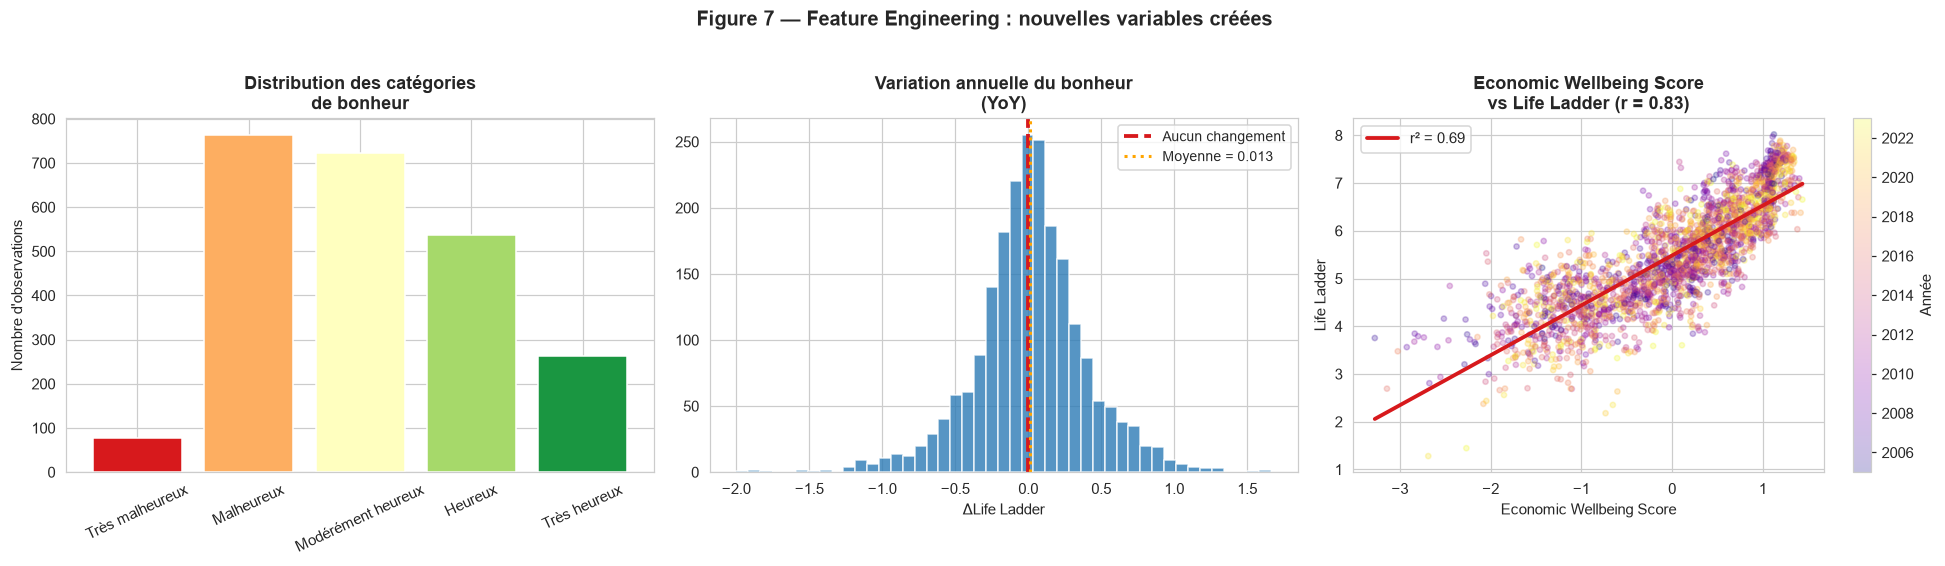

In [23]:
# ── Visualisation des 3 nouvelles variables continues ────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# a) Happiness categories
colors_cat  = ['#d7191c', '#fdae61', '#ffffbf', '#a6d96a', '#1a9641']
cat_counts  = df_clean['happiness_category'].value_counts().sort_index()
axes[0].bar(cat_counts.index, cat_counts.values, color=colors_cat, edgecolor='white')
axes[0].set_title('Distribution des catégories\nde bonheur', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=25)
axes[0].set_ylabel('Nombre d\'observations')

# b) YoY distribution
yoy_data = df_clean['life_ladder_yoy'].dropna()
axes[1].hist(yoy_data, bins=45, color=COLOR_PRIMARY, edgecolor='white', alpha=0.8)
axes[1].axvline(0, color=COLOR_ACCENT, linestyle='--', linewidth=2.5, label='Aucun changement')
axes[1].axvline(yoy_data.mean(), color='orange', linestyle=':', linewidth=2,
                label=f'Moyenne = {yoy_data.mean():.3f}')
axes[1].set_title('Variation annuelle du bonheur\n(YoY)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('ΔLife Ladder')
axes[1].legend(fontsize=9)

# c) Economic Wellbeing Score vs Life Ladder
sc = axes[2].scatter(
    df_clean['economic_wellbeing_score'], df_clean['life_ladder'],
    c=df_clean['year'], cmap='plasma', alpha=0.25, s=12
)
plt.colorbar(sc, ax=axes[2], label='Année')
m, b, r, _, _ = stats.linregress(df_clean['economic_wellbeing_score'], df_clean['life_ladder'])
x_l = np.linspace(df_clean['economic_wellbeing_score'].min(),
                  df_clean['economic_wellbeing_score'].max(), 100)
axes[2].plot(x_l, m * x_l + b, color=COLOR_ACCENT, linewidth=2.5, label=f'r² = {r**2:.2f}')
axes[2].set_title(f'Economic Wellbeing Score\nvs Life Ladder (r = {r:.2f})',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Economic Wellbeing Score')
axes[2].set_ylabel('Life Ladder')
axes[2].legend()

plt.suptitle('Figure 7 — Feature Engineering : nouvelles variables créées',
             fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/07_feature_engineering.png', bbox_inches='tight')
plt.show()

---
## 5. Vérification finale et export

In [24]:
# ── Bilan des colonnes du dataset final ──────────────────────
print(f'Dimensions finales : {df_clean.shape[0]:,} lignes × {df_clean.shape[1]} colonnes')
print(f'Valeurs manquantes : {df_clean[NUMERIC_FEATURES].isnull().sum().sum()}')
print()

groups = [
    ('Identifiants',         ['country', 'year']),
    ('Variables originales', ['life_ladder'] + NUMERIC_FEATURES),
    ('Min-Max [0,1]',        [f'{c}_minmax' for c in NUMERIC_FEATURES]),
    ('Z-score',              [f'{c}_zscore' for c in NUMERIC_FEATURES]),
    ('Features créées',      ['happiness_category', 'life_ladder_yoy', 'net_affect', 'economic_wellbeing_score']),
]
for group_name, cols in groups:
    print(f'  [{group_name}]  ({len(cols)} colonnes)')
    for c in cols:
        print(f'    • {c}  ({df_clean[c].dtype})')
    print()

Dimensions finales : 2,363 lignes × 31 colonnes
Valeurs manquantes : 0

  [Identifiants]  (2 colonnes)
    • country  (str)
    • year  (int64)

  [Variables originales]  (9 colonnes)
    • life_ladder  (float64)
    • log_gdp_per_capita  (float64)
    • social_support  (float64)
    • healthy_life_expectancy  (float64)
    • freedom  (float64)
    • generosity  (float64)
    • corruption  (float64)
    • positive_affect  (float64)
    • negative_affect  (float64)

  [Min-Max [0,1]]  (8 colonnes)
    • log_gdp_per_capita_minmax  (float64)
    • social_support_minmax  (float64)
    • healthy_life_expectancy_minmax  (float64)
    • freedom_minmax  (float64)
    • generosity_minmax  (float64)
    • corruption_minmax  (float64)
    • positive_affect_minmax  (float64)
    • negative_affect_minmax  (float64)

  [Z-score]  (8 colonnes)
    • log_gdp_per_capita_zscore  (float64)
    • social_support_zscore  (float64)
    • healthy_life_expectancy_zscore  (float64)
    • freedom_zscore  (float6

In [25]:
# ── Export CSV ────────────────────────────────────────────────
OUTPUT_PATH = 'World-happiness-report-cleaned.csv'
df_clean.to_csv(OUTPUT_PATH, index=False)

# ── Vérification post-export ──────────────────────────────────
df_check = pd.read_csv(OUTPUT_PATH)
assert df_check.shape == df_clean.shape, 'Erreur : dimensions différentes après relecture'

file_kb = os.path.getsize(OUTPUT_PATH) / 1024
print(f'✅ Dataset nettoyé exporté : "{OUTPUT_PATH}"')
print(f'   Taille   : {file_kb:.0f} Ko')
print(f'   Lignes   : {df_check.shape[0]:,}')
print(f'   Colonnes : {df_check.shape[1]}')
print()
print('Figures générées :')
for f in sorted(os.listdir('figures')):
    print(f'  • figures/{f}')

✅ Dataset nettoyé exporté : "World-happiness-report-cleaned.csv"
   Taille   : 1021 Ko
   Lignes   : 2,363
   Colonnes : 31

Figures générées :
  • figures/01_missing_values.png
  • figures/02_boxplots_outliers.png
  • figures/03_life_ladder_analysis.png
  • figures/04_correlation_matrix.png
  • figures/05_rankings_latest_year.png
  • figures/06_imputation_comparison.png
  • figures/07_feature_engineering.png


---
## Conclusion

### Dataset final : `World-happiness-report-cleaned.csv`

| Groupe | Colonnes | Détail |
|---|---|---|
| Identifiants | 2 | `country`, `year` |
| Variables originales nettoyées | 9 | Life Ladder + 8 indicateurs, renommés snake_case |
| Normalisation Min-Max | 8 | Suffixe `_minmax` — pour les visualisations |
| Standardisation Z-score | 8 | Suffixe `_zscore` — pour les analyses statistiques |
| Features engineered | 4 | `happiness_category`, `life_ladder_yoy`, `net_affect`, `economic_wellbeing_score` |
| **TOTAL** | **31** | |

### Choix clés documentés

| Décision | Justification |
|---|---|
| Interpolation linéaire intra-pays (Passe 1) | Préserve les tendances temporelles du panel |
| Médiane globale (Passe 3) | Robustesse aux distributions asymétriques |
| Min-Max ET Z-score | Deux usages distincts : viz vs. stats |
| `life_ladder` non normalisé | Interprétabilité conservée (échelle de Cantril) |
| Outliers conservés | Valeurs réelles (pays extrêmes), non des erreurs |
| Haïti 2006–2010 | Signalé comme anomalie probable, corrigé par interpolation |

---